# Visualization of geodesic ray transforms

In [47]:
from typing import NamedTuple
from warnings import filterwarnings

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from scipy.integrate import simpson, solve_ivp
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import bisect
from skimage.io import imread
from skimage.transform import radon

## Configuration

Phantom as an image file.

In [48]:
phantom_path = "data/banana_lowres.jpg"

Visualize the phantom.

Width of the phantom 100 (must have width=height)


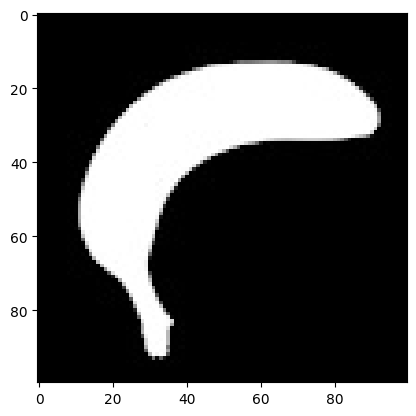

In [49]:
ph = imread(phantom_path).astype(float)
if ph.ndim == 3:  # RGB -> grayscale by averaging
    ph = ph.mean(axis=2)
ph = np.clip(ph, 0, None)
ph = ph / ph.max()

Nph = ph.shape[0]

plt.imshow(ph, cmap="gray")
print(f"Width of the phantom {Nph} (must have width=height)")

Wave speed as a symbolic expression.

In [50]:
from sympy.abc import x, y

c_sym = 1 - 0.5 * sp.exp(-4 * (x**2 + y**2))

Visualize the wave speed.

In [51]:
def c_for_canvas(c_sym):
    c = sp.lambdify([x, y], c_sym)
    xs = np.linspace(-1, 1, Nph)
    Xs, Ys = np.meshgrid(xs, xs)
    return c(Xs, Ys) - 1


def berlin_norm(content):
    return mcolors.TwoSlopeNorm(
        vmin=np.min(content) - 0.1,
        vcenter=0,
        vmax=np.max(content) + 0.1,
    )

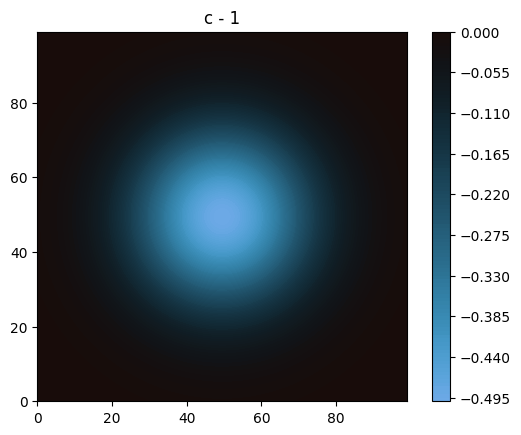

In [52]:
Cs = c_for_canvas(c_sym)
plt.gca().set_title("c - 1")
plt.contourf(Cs, 100, cmap="berlin", norm=berlin_norm(Cs))
plt.colorbar()
plt.gca().set_aspect("equal")

Color palette for plots.

In [53]:
palette = {
    "purple": np.array([186, 0, 255]) / 255,
    "yellow": np.array([246, 255, 0]) / 255,
    "detcolor": np.array([70, 173, 211]) / 255,
    "Xraycolor": np.array([236, 86, 47]) / 255,
    "Xray_darker_color": np.array([151, 55, 30]) / 255,
}

Visualize the color palette.

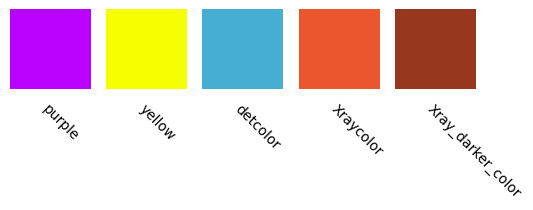

In [54]:
fig, axes = plt.subplots(1, len(palette))
scaling = 1.2
fig.set_size_inches(scaling * len(palette), scaling)
for ax, (name, rgb) in zip(axes, palette.items()):
    plt.sca(ax)
    plt.imshow(np.tile(rgb, (1, 1, 1)))
    plt.text(
        0.5,
        -0.15,
        name,
        transform=ax.transAxes,
        rotation=-45,
        ha="left",
        va="top",
        clip_on=False,
        rotation_mode="anchor",
    )
    plt.axis("off")

Default parameters for plotting. Any number of default values can be overridden when instantiating `PlotParams` (without touching the defaults). 

In [55]:
class PlotParams(NamedTuple):
    """
    Parameters controlling plotting.

    msize         : source-dot marker size
    detlength     : detector line length
    detwidth      : detector line width
    raywidth      : X-ray line width
    datalinewidth : projection-data line width
    projamp       : amplitude of projection data in plot units
    projoff       : offset of projection data from detector
    Gammascorr     : gamma correction for the displayed phantom
    """

    msize: int = 6
    detlength: float = 3
    detwidth: float = 1.2
    raywidth: float = 1
    datalinewidth: float = 2.0
    projamp: float = 1
    projoff: float = 0.15
    gammacorr: float = 0.5


pp = PlotParams()

## Canvas coordinates vs computational coordinates

The phantom is at the center of a canvas. 

In [56]:
def canvas(content=None):
    out = np.zeros((3 * Nph, 3 * Nph))
    if content is not None:
        out[Nph : 2 * Nph, Nph : 2 * Nph] = content
    return out


ph_in_canvas = canvas(np.power(ph, pp.gammacorr))

In computations, we use such coordinates that the phantom (which is assumed to be a square) is in $[-1,1]^2$ and the canvas is $[-3,3]^2$. The following functions give the transformation between the canvas and computational coordinates.

In [57]:
def to_canvas(x):
    return Nph * (x + 3) / 2


def from_canvas(y):
    return y * 2 / Nph - 3

When plotting with `imshow` canvas coordinates are used. By default, `imshow` gives inverted orientation for y-axis. We will use systematically `origin='lower'` to have the usual orientation. 

When evaluating the phantom in computational coordinates, we use simple interpolation. This is good enough for our visualization purposes. Interpolation with `RegularGridInterpolator` gives array-axis order, that is, rows are indexed before columns. This is opposite to the geometric xy-order. For this reason, we pass transposed phantom to the interpolator. 

In [58]:
def plot_canvas(canvas, cmap="gray", norm=None):
    plt.imshow(canvas, cmap=cmap, norm=norm, origin="lower")


def plot_phantom():
    plot_canvas(ph_in_canvas)


def plot_c(c, norm):
    plot_canvas(canvas(c), cmap="berlin", norm=norm)


xs = from_canvas(np.arange(Nph, 2 * Nph))
ph_interp = RegularGridInterpolator(
    (xs, xs), ph.T, method="cubic", bounds_error=False, fill_value=0
)

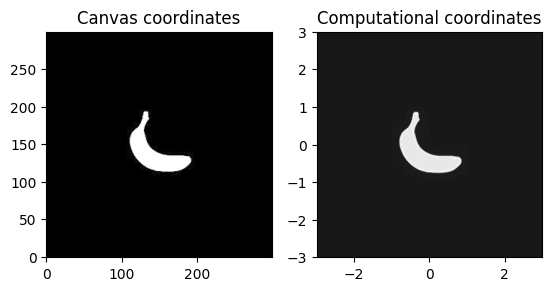

In [59]:
fig, axes = plt.subplots(1, 2)

plt.sca(axes.flat[0])
plt.gca().set_title("Canvas coordinates")
plot_phantom()

plt.sca(axes.flat[1])
plt.gca().set_title("Computational coordinates")
xs = np.linspace(-3, 3, 3 * Nph)
Xs, Ys = np.meshgrid(xs, xs)
Zs = ph_interp((Xs, Ys))
plt.contourf(Xs, Ys, Zs, 100, cmap="gray")
plt.gca().set_aspect("equal")

## Source geometry

The sources are on the line segment $\{-1\} \times [-1,1]$ emitting to the direction $(1,0)$. This source geometry can be rotated around the origin. 

In [60]:
def sources(th=0, Nrays=10):
    rmat = np.array(
        [[np.cos(-th), -np.sin(-th)], [np.sin(-th), np.cos(-th)]]
    )
    return rmat @ np.stack(
        [np.full(Nrays, -1), np.linspace(-1, 1, Nrays)]
    ), rmat @ [1, 0]

Visualize the sources.

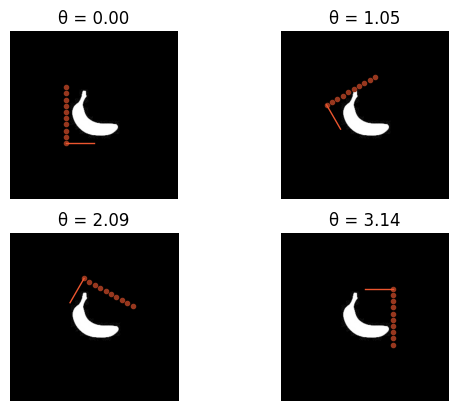

In [61]:
fig, axes = plt.subplots(2, 2)
ths = np.linspace(0, np.pi, 4)

for ax, th in zip(axes.flat, ths):
    plt.sca(ax)
    plot_phantom()

    src_pts, src_dir = sources(th=th)

    # Source points
    plt.plot(
        *to_canvas(src_pts),
        ".",
        color=palette["Xray_darker_color"],
        markersize=pp.msize,
    )

    # Source direction
    p0 = src_pts[:, 0]
    plt.plot(
        *to_canvas(np.stack([p0, p0 + src_dir]).T),
        "-",
        color=palette["Xraycolor"],
        linewidth=1,
    )

    plt.gca().set_title(f"θ = {th:.2f}")
    plt.gca().axis("off")

## Visualization of projections

The projection is parametrized by source, not by receiver, since the rays don't align nicely on the opposite side in the non-Euclidean case. We visualize the projections on the source side as this is less confusing.

In [62]:
def plot_pr(pr, MAXsino, th=0):
    src_pts, src_dir = sources(th=th, Nrays=2)

    p0 = src_pts[:, 0]
    p1 = src_pts[:, 1]

    amp = pp.projoff + pr * pp.projamp / MAXsino
    ss = np.linspace(0, 1, len(amp))
    ps = np.array(
        [
            s * p1 + (1 - s) * p0 - a * src_dir
            for (s, a) in zip(ss, amp)
        ]
    )
    plt.plot(
        *to_canvas(ps.T),
        "-",
        color=palette["yellow"],
        linewidth=pp.datalinewidth,
    )

Test the visualization.

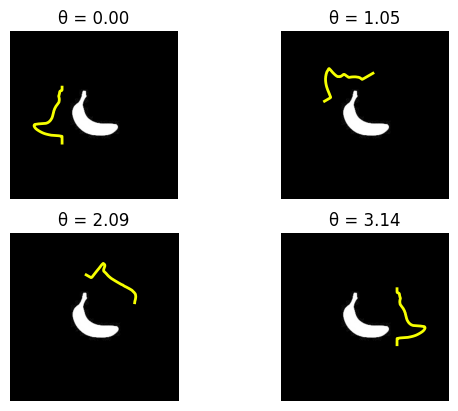

In [63]:
fig, axes = plt.subplots(2, 2)
ths = np.linspace(0, np.pi, 4)
ths_d = -90 + np.degrees(ths)

filterwarnings("ignore", message="Radon transform:.*")
sinogram = radon(ph, theta=ths_d).T
MAXsino = np.max(sinogram)

for ax, th, pr in zip(axes.flat, ths, sinogram):
    plt.sca(ax)
    plot_phantom()
    plot_pr(pr, MAXsino, th)
    plt.gca().set_title(f"θ = {th:.2f}")
    plt.gca().axis("off")

## Geodesics

Compute the Christoffel symbols and define the geodesic vector field G.

In [64]:
def Gamma(i, k, l, c):
    g = c ** (-2) * sp.eye(2)
    g_inv = g.inv()
    p = [x, y]
    ix = [0, 1]
    out = 0
    for m in ix:
        term = (
            sp.diff(g[m, k], p[l])
            + sp.diff(g[m, l], p[k])
            - sp.diff(g[k, l], p[m])
        )
        out += 1 / 2 * g_inv[i, m] * term
    return sp.lambdify(p, sp.simplify(out))


def Gammas(c):
    ix = [0, 1]
    return [[[Gamma(i, k, l, c) for l in ix] for k in ix] for i in ix]


def G(t, u, Gammas):
    out = np.array([u[2], u[3], 0, 0])
    for k in [0, 1]:
        for l in [0, 1]:
            out[2] -= (
                Gammas[0][k][l](u[0], u[1]) * u[k + 2] * u[l + 2]
            )
            out[3] -= (
                Gammas[1][k][l](u[0], u[1]) * u[k + 2] * u[l + 2]
            )
    return out

Solver for geodesics.

In [65]:
def solve_geod(src_pt, src_dir, Gammas, t_max=5.5):
    u0 = np.concatenate([src_pt, src_dir])
    f = lambda t, u: G(t, u, Gammas)
    return solve_ivp(
        f,
        (0, t_max),
        u0,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        dense_output=True,
    )

Visualization of geodesics.

All the geodesics must exit.


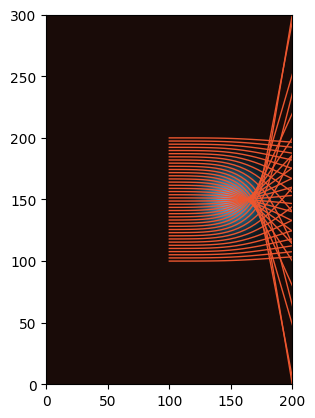

In [66]:
Gammas_c = Gammas(c_sym)

content = c_for_canvas(c_sym)
plot_c(content, berlin_norm(content))

src_pts, src_dir = sources(Nrays=40)
for src_pt in src_pts.T:
    sol = solve_geod(src_pt, src_dir, Gammas_c)
    ts = np.linspace(0, sol.t[-1])
    gamma = sol.sol(ts)[0:2, :]

    plt.plot(
        *to_canvas(gamma),
        "-",
        color=palette["Xraycolor"],
        linewidth=pp.raywidth,
    )

plt.gca().set_xlim(0, 2 * Nph)
plt.gca().set_ylim(0, 3 * Nph)

print("All the geodesics must exit.")

## Exit times

Truncation to exit times is not very robust. We assume that the goedesic given by the solver has exited.   

In [67]:
def dist_to_src_line(p, th=0):
    _, src_dir = sources(th=th, Nrays=2)
    return src_dir @ p + 1


def exit_time(sol, th=0):
    f = lambda t: dist_to_src_line(sol.sol(t)[0:2], th=th) - 2
    return bisect(f, sol.t[0], sol.t[-1])

Visualization of the geodesics and detector.

In [68]:
def plot_detector(th=0):
    src_pts, src_dir = sources(th=th, Nrays=2)
    p0 = src_pts[:, 0] + 2 * src_dir
    p1 = src_pts[:, 1] + 2 * src_dir
    p = (p1 + p0) / 2
    v = p1 - p0
    v = v / np.linalg.norm(v)
    p0 = p - v * pp.detlength / 2
    p1 = p + v * pp.detlength / 2

    plt.plot(
        *to_canvas(np.stack([p0, p1]).T),
        "-",
        color=palette["detcolor"],
        linewidth=pp.detwidth,
    )


def plot_geod(sol, th=0):
    t = exit_time(sol, th=th)
    ts = np.linspace(0, t)
    gamma = sol.sol(ts)[0:2, :]

    plt.plot(
        *to_canvas(gamma),
        "-",
        color=palette["Xraycolor"],
        linewidth=pp.raywidth,
    )

Test the visualization.

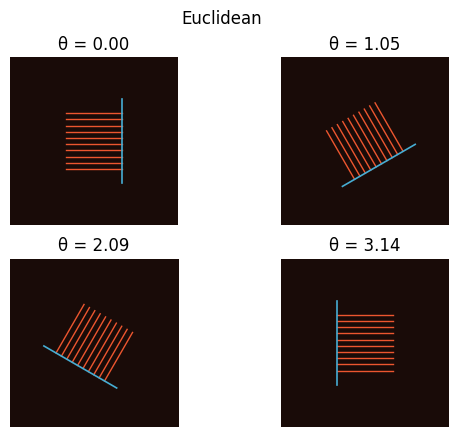

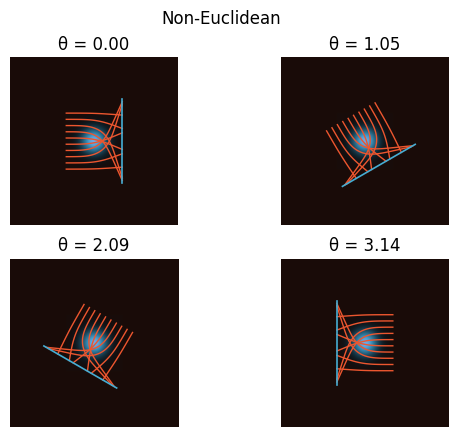

In [69]:
c_syms = [1, c_sym]
titles = ["Euclidean", "Non-Euclidean"]

for c_sym, title in zip(c_syms, titles):
    fig, axes = plt.subplots(2, 2)
    fig.suptitle(title)
    ths = np.linspace(0, np.pi, 4)

    content = c_for_canvas(c_sym=c_sym)
    norm = berlin_norm(content)
    Gammas_c = Gammas(c_sym)

    for ax, th in zip(axes.flat, ths):
        plt.sca(ax)
        plot_c(content, norm)

        src_pts, src_dir = sources(th=th)
        for src_pt in src_pts.T:
            plot_geod(solve_geod(src_pt, src_dir, Gammas_c), th=th)

        plot_detector(th=th)
        plt.gca().set_title(f"θ = {th:.2f}")
        plt.gca().axis("off")

## Projections

As the phantom is discontinuous, use composite Simpson for numerical integration.

In [70]:
def project(Gammas, Nrays=20, th=0):
    out = np.zeros(Nrays)
    src_pts, src_dir = sources(th=th, Nrays=Nrays)
    for i in range(Nrays):
        src_pt = src_pts[:, i]
        sol = solve_geod(src_pt, src_dir, Gammas)
        t = exit_time(sol, th=th)

        def f(t):
            u = sol.sol(t)
            return float(ph_interp((u[0], u[1])))

        ts = np.linspace(0, t)
        fts = np.array([f(t) for t in ts])
        out[i] = simpson(fts, x=ts)
    return out

Compare with `radon` (after normalization) in the case of Euclidean geometry.

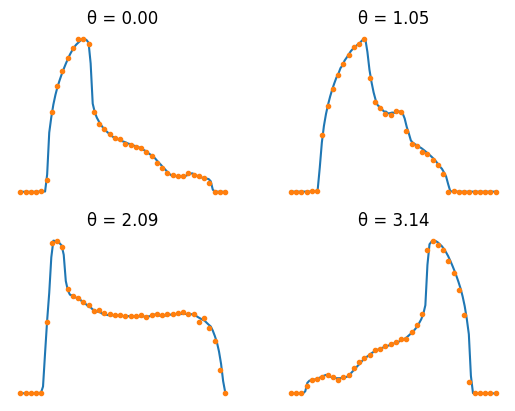

In [71]:
Gammas_c = Gammas(1)
Nrays = 40

fig, axes = plt.subplots(2, 2)
ths = np.linspace(0, np.pi, 4)

xs_radon = np.linspace(-1, 1, Nph)
xs_project = np.linspace(-1, 1, Nrays)

for ax, th in zip(axes.flat, ths):
    plt.sca(ax)
    th_d = -90 + np.degrees(th)
    pr = radon(ph, theta=[th_d])
    pr = pr / np.max(pr)
    plt.plot(xs_radon, pr)

    pr = project(Gammas_c, Nrays=Nrays, th=th)
    pr = pr / np.max(pr)
    plt.plot(xs_project, pr, ".")

    plt.gca().set_title(f"θ = {th:.2f}")
    plt.gca().axis("off")

## Interpolating between Euclidean geometry and a strong lens

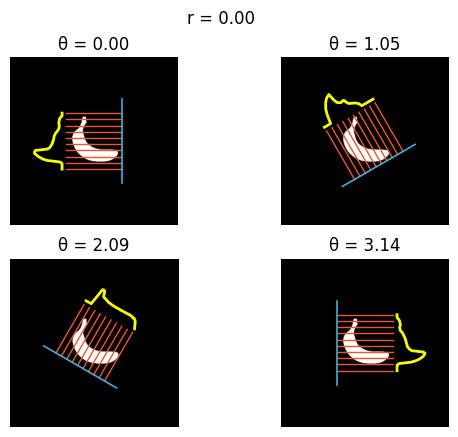

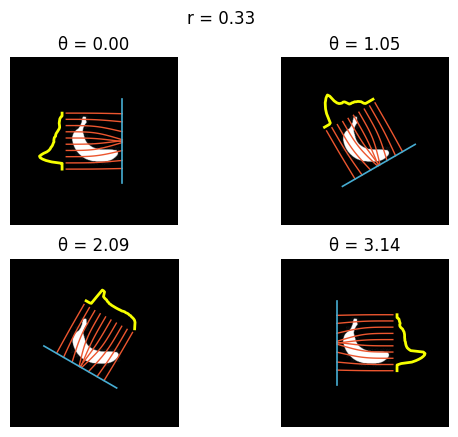

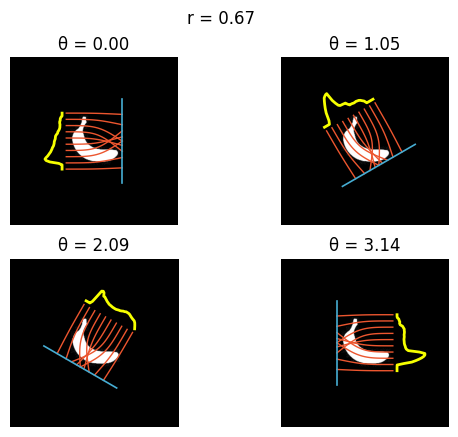

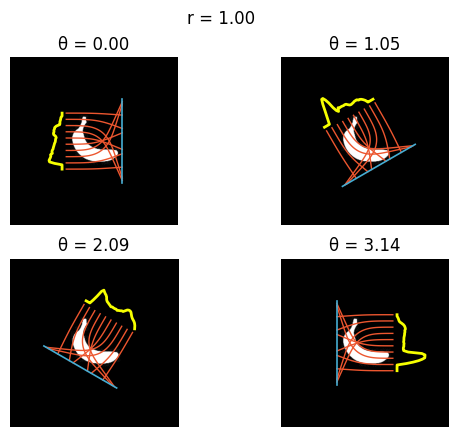

In [72]:
rs = np.linspace(0, 1, 4)
Nrays = 40

for r in rs:
    c = r * c_sym + (1 - r)
    Gammas_c = Gammas(c)

    fig, axes = plt.subplots(2, 2)
    fig.suptitle(f"r = {r:.2f}")
    ths = np.linspace(0, np.pi, 4)

    prs = np.zeros((len(rs), Nrays))
    for i in range(len(ths)):
        prs[i, :] = project(Gammas_c, Nrays=Nrays, th=ths[i])
    prs_max = np.max(prs)

    for i in range(len(ths)):
        plt.sca(axes.flat[i])
        th = ths[i]
        pr = prs[i, :]

        plot_phantom()

        src_pts, src_dir = sources(th=th)
        for src_pt in src_pts.T:
            plot_geod(solve_geod(src_pt, src_dir, Gammas_c), th=th)

        plot_pr(pr, prs_max, th=th)

        plot_detector(th=th)
        plt.gca().set_title(f"θ = {th:.2f}")
        plt.gca().axis("off")